# 1. Cost-Sensitive Learning: Handling Class Imbalance with `class_weight`

This notebook covers:
1. **The Imbalance Trap & The Accuracy Paradox**: Why standard models achieve 95%+ accuracy while failing completely on the minority class.
2. **The Mathematics of `class_weight='balanced'`**: How Scikit-Learn scales loss gradients proportionally to class frequencies.
3. **Training Baseline vs. Cost-Sensitive Models**: Comparing unweighted and balanced models across `LogisticRegression` and `RandomForestClassifier`.
4. **Custom Cost Matrices (`class_weight={0: 1, 1: 10}`)**: Tuning penalty ratios to reflect asymmetric business costs.
5. **Proper Evaluation**: Focusing on Confusion Matrix, Recall, Precision, and F1-Score instead of raw Accuracy.

In [1]:
import numpy as np
import pandas as pd
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Generate a synthetic fraud detection dataset with a 95:5 class imbalance
X_raw, y_raw = make_classification(
    n_samples=1000,
    n_features=6,
    n_informative=4,
    n_redundant=1,
    weights=[0.95, 0.05],  # 95% Class 0 (Legit), 5% Class 1 (Fraud)
    flip_y=0,
    random_state=42
)

# Convert to DataFrame
feature_names = [f"Feature_{i+1}" for i in range(X_raw.shape[1])]
df = pd.DataFrame(X_raw, columns=feature_names)
df['Is_Fraud'] = y_raw

print("=== 1. CLASS DISTRIBUTION ===")
display(df['Is_Fraud'].value_counts(normalize=True).rename('Proportion').to_frame().assign(
    Count=df['Is_Fraud'].value_counts()
))

=== 1. CLASS DISTRIBUTION ===


,Proportion,Count
Is_Fraud,,
0,0.95,950
1,0.05,50


In [2]:
display(df)

,Feature_1,Feature_2,Feature_3,Feature_4,Feature_5,Feature_6,Is_Fraud
0,-2.062806,1.349630,0.592102,-1.679421,3.053408,0.357603,0
1,-1.076196,-0.294657,0.662782,-3.270125,2.622054,0.080713,0
2,-2.407619,1.722726,0.381168,-0.042070,2.502862,1.168427,0
3,-1.279506,1.104792,0.198774,-0.191471,1.546835,1.016459,0
4,0.217687,-3.430056,-0.671144,-0.111399,-1.777715,-2.605821,0
...,...,...,...,...,...,...,...
995,-1.141490,-1.103260,-1.277536,-1.205530,0.957252,-1.025348,0
996,-0.116789,-1.890140,0.881585,0.328725,-1.067478,-1.546102,0
997,-2.121328,-0.596296,0.446894,-2.805718,2.973481,0.888875,0
998,-1.150930,-0.742749,-0.470303,-1.194539,1.092071,-1.331861,0


---
## Part 1: Train / Test Split (Stratified)

We perform an 80/20 train/test split.
* **`stratify=y` is mandatory**: Ensures both the training and test sets contain the exact same 95:5 class distribution.

In [3]:
X = df.drop(columns=['Is_Fraud']).copy()
y = df['Is_Fraud'].copy()

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.20, random_state=42, stratify=y)

print(f"Train Set Shape: {X_train.shape} | Fraud Cases: {y_train.sum()} ({y_train.mean():.1%})")
print(f"Test Set Shape:  {X_test.shape}  | Fraud Cases: {y_test.sum()} ({y_test.mean():.1%})")

Train Set Shape: (800, 6) | Fraud Cases: 40 (5.0%)
Test Set Shape:  (200, 6)  | Fraud Cases: 10 (5.0%)


---
## Part 2: The Baseline (Unweighted) Model & The Accuracy Paradox

When unweighted, the loss function treats every error equally. Because 95% of rows are Class 0, the model maximizes overall accuracy simply by predicting Class 0 almost every time.

In [4]:
# Train a standard, unweighted Logistic Regression model
baseline_lr = LogisticRegression(random_state=42)
baseline_lr.fit(X_train, y_train)

y_pred_baseline = baseline_lr.predict(X_test)

print("=== BASELINE (UNWEIGHTED) LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_baseline, target_names=['Legit (0)', 'Fraud (1)'], zero_division=0))

=== BASELINE (UNWEIGHTED) LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

   Legit (0)       0.95      1.00      0.97       190
   Fraud (1)       0.00      0.00      0.00        10

    accuracy                           0.95       200
   macro avg       0.47      0.50      0.49       200
weighted avg       0.90      0.95      0.93       200



---
## Part 3: The Math Behind `class_weight='balanced'`

Instead of modifying the dataset (e.g., duplicating or deleting rows), `class_weight='balanced'` **modifies the loss function**.

### The Weight Formula (Scikit-Learn):
$$w_j = \frac{N_{\text{total}}}{K \times N_j}$$

Where:
* $N_{\text{total}}$ = Total number of samples in training data
* $K$ = Total number of classes ($2$ for binary classification)
* $N_j$ = Number of samples in class $j$

#### Concrete Calculation on our Training Set ($N=800$):
* **Class 0 (760 samples):** $w_0 = \frac{800}{2 \times 760} = \frac{800}{1520} \approx \mathbf{0.526}$
* **Class 1 (40 samples):** $w_1 = \frac{800}{2 \times 40} = \frac{800}{80} = \mathbf{10.0}$

**The Result:** The model is penalized **$19\times$ harder** for misclassifying a single Fraud case compared to a Legit case.

In simple words just remember it like: we treat this issue buy adding some new variable $w$ to the loss functions, which penalize the loss we get from minority class more than loss from majority class, which gives equal contribution to the total loss, rather than the majority class dominating all. and that $w0$ and $w1$ is automatically calculated by sklearn as we add that parameter, and also the calculation is above.
 

In [6]:
balance_lr = LogisticRegression(class_weight='balanced', random_state=42)
balance_lr.fit(X_train, y_train)
y_pred_balanced_lr = balance_lr.predict(X_test)

balanced_rf = RandomForestClassifier(class_weight='balanced', n_estimators=100, random_state=42)
balanced_rf.fit(X_train, y_train)
y_pred_balanced_rf = balanced_rf.predict(X_test)

print("=== 1. BALANCED LOGISTIC REGRESSION ===")
print(classification_report(y_test, y_pred_balanced_lr, target_names=['Legit (0)', 'Fraud (1)']))

print("\n=== 2. BALANCED RANDOM FOREST ===")
print(classification_report(y_test, y_pred_balanced_rf, target_names=['Legit (0)', 'Fraud (1)']))

=== 1. BALANCED LOGISTIC REGRESSION ===
              precision    recall  f1-score   support

   Legit (0)       0.97      0.76      0.85       190
   Fraud (1)       0.10      0.50      0.17        10

    accuracy                           0.75       200
   macro avg       0.53      0.63      0.51       200
weighted avg       0.92      0.75      0.82       200


=== 2. BALANCED RANDOM FOREST ===
              precision    recall  f1-score   support

   Legit (0)       0.96      1.00      0.98       190
   Fraud (1)       1.00      0.30      0.46        10

    accuracy                           0.96       200
   macro avg       0.98      0.65      0.72       200
weighted avg       0.97      0.96      0.96       200



---
## Deep Dive: Analyzing the Results & The Trade-Offs

### 1. The Baseline (Unweighted) Logistic Regression: The "Lazy" Model
* **Accuracy is 95% (A Lie):** Out of 200 test cases, 190 are Legit and 10 are Fraud. The model simply predicted `Legit (0)` for all 200 records.
* **Recall on Fraud is 0.00 (0%):** It caught **0 out of 10** fraud attacks.
* **Why it happened:** Without class weights, the optimizer minimized total loss by ignoring the 10 fraud cases completely. In production, this model is **completely useless**.

---

### 2. Balanced Logistic Regression: The Aggressive Model
* **Recall on Fraud jumped from 0.00 $\to$ 0.50 (50%):** It successfully detected **5 out of the 10** fraud cases.
* **Precision on Fraud is 0.10 (10%):** Because the model is penalized heavily for missing fraud, it became much more cautious and flagged many borderline legit transactions as fraud (raising false alarms).
* **Overall Accuracy dropped to 75%:** This is expected. We willingly sacrificed overall accuracy to gain the ability to catch fraud.

---

### 3. Balanced Random Forest: The Precision Champion
* **Precision on Fraud is 1.00 (100%):** When Random Forest flags a transaction as Fraud, it is **100% correct** (zero false alarms).
* **Recall on Fraud is 0.30 (30%):** It caught **3 out of 10** fraud cases.
* **Why it behaved differently from Logistic Regression:**
  * Logistic Regression draws a single flat boundary across the feature space, leading to more false alarms when shifted.
  * Random Forest builds complex non-linear boxes (decision trees) around the minority points. It only predicts fraud when it is highly certain, resulting in perfect precision but lower recall on this small sample.

---

### 4. Summary Metric Comparison

| Model | Fraud Recall (Catch Rate) | Fraud Precision (True Alarm Rate) | Overall Accuracy | Business Verdict |
| :--- | :---: | :---: | :---: | :--- |
| **Unweighted LR** | `0%` | `0%` | `95%` | **Broken:** Completely ignores the business objective. |
| **Balanced LR** | `50%` | `10%` | `75%` | **Aggressive:** Catches the most fraud, but causes many false alarms. |
| **Balanced RF** | `30%` | `100%` | `96%` | **Conservative:** Never creates false alarms, but misses some fraud cases. |

---

---
## Part 4: Custom Cost Matrices for Asymmetric Business Loss

In production, business stakeholders often dictate specific cost trade-offs.
* Example: A false positive (investigating an innocent customer) costs $\$10$ in manual review.
* A false negative (missing a fraud attack) costs $\$200$ in chargebacks.
* Cost ratio: $20:1$. We pass this directly via a dictionary: `class_weight={0: 1, 1: 20}`.

In [8]:
# Define custom business penalty ratio (1:15)
custom_weights = {0: 1, 1: 15}

custom_lr = LogisticRegression(class_weight=custom_weights, random_state=42)
custom_lr.fit(X_train, y_train)
y_pred_custom_lr = custom_lr.predict(X_test)

print("=== LOGISTIC REGRESSION WITH CUSTOM WEIGHTS {0: 1, 1: 15} ===")
print(classification_report(y_test, y_pred_custom_lr, target_names=['Legit (0)', 'Fraud (1)']))

=== LOGISTIC REGRESSION WITH CUSTOM WEIGHTS {0: 1, 1: 15} ===
              precision    recall  f1-score   support

   Legit (0)       0.96      0.85      0.90       190
   Fraud (1)       0.12      0.40      0.19        10

    accuracy                           0.82       200
   macro avg       0.54      0.62      0.54       200
weighted avg       0.92      0.82      0.87       200



---
## Part 5: Side-by-Side Confusion Matrix Evaluation

We visually evaluate how shifting class weights directly controls the False Negative rate (missed fraud).

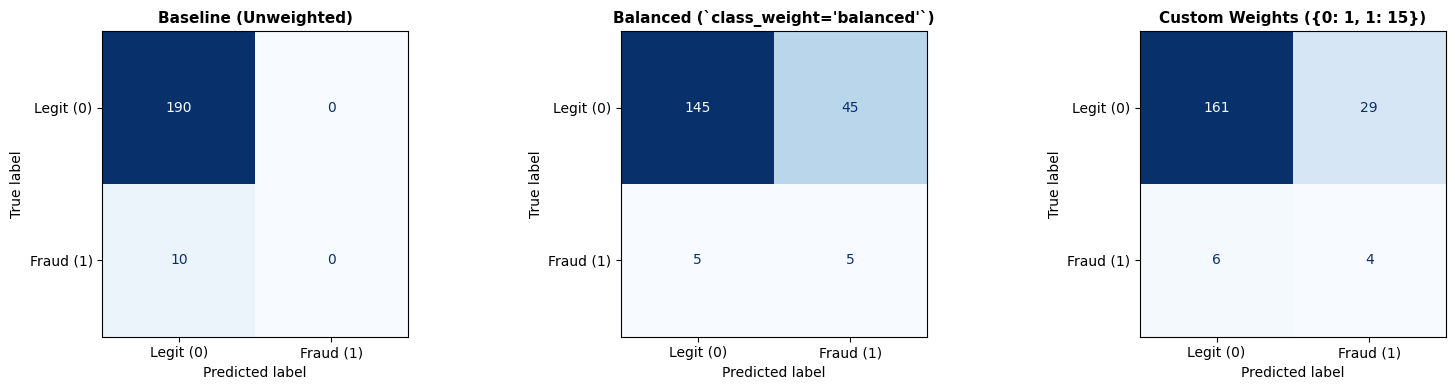

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

models = [
    ("Baseline (Unweighted)", y_pred_baseline),
    ("Balanced (`class_weight='balanced'`)", y_pred_balanced_lr),
    ("Custom Weights ({0: 1, 1: 15})", y_pred_custom_lr)
]

for ax, (title, preds) in zip(axes, models):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Legit (0)', 'Fraud (1)'])
    disp.plot(ax=ax, cmap='Blues', colorbar=False)
    ax.set_title(title, fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

---
## Key Takeaways

1. **Accuracy is Deceptive**: Always evaluate imbalanced problems using **Recall**, **Precision**, and **F1-Score**.
2. **Zero Overhead**: `class_weight='balanced'` costs zero extra memory or compute because no new data points are created.
3. **Trade-off Mechanism**: Increasing minority class weight boosts **Recall** (catches more fraud) at the expected expense of **Precision** (more false alarms).